# Vessel Oil-Spill Risk Scoring from AIS Data## SATVIGIL — Maritime Module### OverviewFollowing the same core technique as the reference AIS anomaly-detection notebook(train an SVR model to *predict* a vessel's expected speed given its normalfeatures, then flag large deviations between predicted and actual speed asanomalous behavior) — this notebook extends that idea specifically toward**oil spill responsibility scoring**.Anomalous speed/course behavior alone doesn't tell you a vessel caused a spill.So this notebook combines FOUR signals into one final risk score per vessel:1. **Behavioral anomaly** (SVR-predicted vs actual SOG — same method as reference)2. **Vessel type risk** (tankers/cargo carry higher prior spill risk than others)3. **Proximity to the spill location** (haversine distance, closer = more likely)4. **Heading alignment** (does the vessel's course match the direction the slick trails?)### Data SourceSame AIS CSV structure as: https://marinecadastre.gov/ais/Replace with real India-region AIS data (e.g. from Global Fishing Watch) once available.

## 1. Imports

In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltfrom math import radians, sin, cos, sqrt, atan2from sklearn.svm import SVRfrom sklearn.model_selection import train_test_splitfrom sklearn.metrics import r2_score

## 2. Load DataSame loading approach as the reference notebook.

In [2]:
data = pd.read_csv('AIS_data.csv')  # replace with your actual filenamedata.head()

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo
0,419082341,2026-09-04 06:00:00,22.93157,69.54050,6.2,246.4,246.4,MT GUJARAT PRIDE,9082341,VT341,80,0,180,32,11.5,80
1,419082341,2026-09-04 06:05:00,22.92839,69.53198,6.3,249.4,249.4,MT GUJARAT PRIDE,9082341,VT341,80,0,180,32,11.5,80
2,419082341,2026-09-04 06:10:00,22.92521,69.52345,5.5,246.0,246.0,MT GUJARAT PRIDE,9082341,VT341,80,0,180,32,11.5,80
3,419082341,2026-09-04 06:15:00,22.92204,69.51492,6.1,247.5,247.5,MT GUJARAT PRIDE,9082341,VT341,80,0,180,32,11.5,80
4,419082341,2026-09-04 06:20:00,22.91886,69.50639,6.1,246.7,246.7,MT GUJARAT PRIDE,9082341,VT341,80,0,180,32,11.5,80


In [3]:
data.columns

Index(['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading',
       'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length',
       'Width', 'Draft', 'Cargo'],
      dtype='object')

In [4]:
data.describe()

,MMSI,LAT,LON,SOG,COG,Heading,IMO,VesselType,Status,Length,Width,Draft,Cargo
count,9.700000e+02,970.000000,970.000000,970.000000,970.000000,970.000000,9.700000e+02,970.000000,970.0,970.000000,970.000000,970.000000,970.000000
mean,4.190575e+08,22.785575,69.129632,9.408866,194.721546,194.721546,9.057528e+06,63.400000,0.0,117.600000,21.600000,7.900000,62.000000
std,2.862852e+04,0.201586,0.432099,3.982716,83.622920,83.622920,2.862852e+04,19.068688,0.0,76.463504,12.743917,4.411356,18.339759
min,4.190110e+08,22.242550,68.011080,1.600000,74.500000,74.500000,9.010987e+06,30.000000,0.0,24.000000,6.000000,2.500000,30.000000
25%,4.190321e+08,22.680240,68.841307,6.000000,110.200000,110.200000,9.032109e+06,50.000000,0.0,24.000000,6.000000,2.500000,50.000000
50%,4.190599e+08,22.773610,69.130955,10.050000,212.500000,212.500000,9.059876e+06,70.500000,0.0,180.000000,32.000000,11.500000,70.000000
75%,4.190823e+08,22.863883,69.400000,12.000000,260.600000,260.600000,9.082341e+06,80.000000,0.0,180.000000,32.000000,11.500000,80.000000
max,4.190999e+08,23.490580,70.391390,17.200000,319.200000,319.200000,9.099887e+06,82.000000,0.0,180.000000,32.000000,11.500000,80.000000


In [5]:
data.dtypes

MMSI              int64
BaseDateTime     object
LAT             float64
LON             float64
SOG             float64
COG             float64
Heading         float64
VesselName       object
IMO               int64
CallSign         object
VesselType        int64
Status            int64
Length            int64
Width             int64
Draft           float64
Cargo             int64
dtype: object

## 3. Data CleaningSame approach as reference: check missing values, then interpolate.

In [6]:
missing_values_columns = data.columns[data.isnull().any()].tolist()missing_values_columns

[]

In [7]:
count_missing_values = []for i in missing_values_columns:    count = data[i].isnull().sum()    count_missing_values.append(count)missing_values_record = pd.DataFrame({'Column name': missing_values_columns,                                       'Missing Value Count': count_missing_values})missing_values_record

,Column name,Missing Value Count


In [8]:
# Linear interpolation for missing values (same as reference notebook)data = data.interpolate(method='linear', axis=0).ffill().bfill()

In [9]:
# Convert BaseDateTime to actual datetime type — required for time-window# filtering and interpolating vessel position at an exact spill timestamp laterdata['BaseDateTime'] = pd.to_datetime(data['BaseDateTime'])data['BaseDateTime'].dtype

dtype('<M8[ns]')

In [10]:
# Extract time features (same as reference notebook)data['hour'] = pd.DatetimeIndex(data['BaseDateTime']).hourdata['day'] = pd.DatetimeIndex(data['BaseDateTime']).daydata['month'] = pd.DatetimeIndex(data['BaseDateTime']).monthdata['year'] = pd.DatetimeIndex(data['BaseDateTime']).year

## 4. Per-Vessel Track ConstructionOne MMSI = one vessel. Same grouping approach as reference notebook, but instead of picking a single vessel manually, we loop over ALL vessels so the anomaly model + risk scoring runs across your whole fleet automatically.

In [11]:
vessel_ids = data['MMSI'].unique()print(f"Number of unique vessels in dataset: {len(vessel_ids)}")

Number of unique vessels in dataset: 10


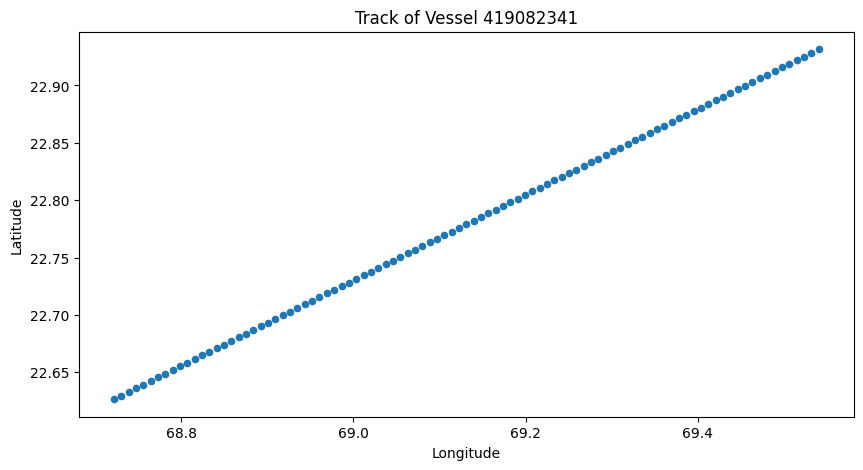

In [12]:
def get_vessel_track(mmsi):    track = data[data['MMSI'] == mmsi].sort_values('BaseDateTime').reset_index(drop=True)    return track# quick visual sanity check on one vessel, same as reference notebook didsample_track = get_vessel_track(vessel_ids[0])sample_track.plot(kind='scatter', x='LON', y='LAT', figsize=(10, 5))plt.title(f"Track of Vessel {vessel_ids[0]}")plt.xlabel("Longitude")plt.ylabel("Latitude")plt.show()

## 5. SVR Anomaly Detection (per vessel)Same technique as reference notebook: train an SVR model to predict SOG from `LAT`, `hour`, `Cargo`, `COG` — then flag rows where actual SOG deviates strongly from predicted SOG as anomalous. This matters for spill risk because ships often slow down or move erratically while illegally discharging oil.

In [13]:
def detect_anomalies_for_vessel(track, deviation_threshold=6):    """    Trains an SVR model on one vessel's own track to predict expected SOG,    then flags rows where |actual - predicted| exceeds deviation_threshold.    Requires enough rows to split into train/test — skips very short tracks.    """    if len(track) < 10:        return pd.DataFrame()  # not enough data for this vessel    X = track[['LAT', 'hour', 'Cargo', 'COG']]    y = track['SOG'].ravel()    try:        x_train, x_test, y_train, y_test = train_test_split(            X, y, test_size=0.3, random_state=4        )        regressor = SVR(gamma='scale', C=100000, epsilon=1, degree=3)        regressor.fit(x_train, y_train)        yhat = np.round(regressor.predict(x_test), 1)        results = pd.DataFrame({'Actual': y_test, 'Predicted': yhat})        results['difference'] = results['Actual'] - results['Predicted']        x_test = x_test.reset_index(drop=True)        anomalies = results[            (results['difference'] >= deviation_threshold) |            (results['difference'] <= -deviation_threshold)        ]        anomaly_rows = x_test.iloc[anomalies.index].copy()        anomaly_rows['MMSI'] = track['MMSI'].iloc[0]        anomaly_rows['speed_deviation'] = anomalies['difference'].values        return anomaly_rows    except Exception as e:        return pd.DataFrame()# Run across all vessels with enough dataall_anomalies = []for mmsi in vessel_ids:    track = get_vessel_track(mmsi)    anomalies = detect_anomalies_for_vessel(track)    if not anomalies.empty:        all_anomalies.append(anomalies)if all_anomalies:    anomaly_df = pd.concat(all_anomalies, ignore_index=True)else:    anomaly_df = pd.DataFrame()print(f"Vessels flagged with anomalous behavior: {anomaly_df['MMSI'].nunique() if not anomaly_df.empty else 0}")anomaly_df.head()

Vessels flagged with anomalous behavior: 0


""


## 6. Haversine Distance FunctionUsed to measure how close each vessel actually was to the spill location at the relevant time — this is your strongest hard evidence signal.

In [14]:
def haversine(lat1, lon1, lat2, lon2):    """Great-circle distance in kilometers between two lat/lon points."""    R = 6371  # Earth radius in km    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])    dlat = lat2 - lat1    dlon = lon2 - lon1    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2    c = 2 * atan2(sqrt(a), sqrt(1 - a))    return R * c

## 7. Define the Spill EventSet this to your actual detected spill's coordinates and timestamp (from your Sentinel-1 scene metadata + CNN model output).

In [15]:
# EXAMPLE VALUES — replace with your real detected spill location/timeSPILL_LAT = 22.75SPILL_LON = 69.10SPILL_TIME = pd.Timestamp('2026-09-04 10:30:00')TIME_WINDOW_HOURS = 12  # look at vessel positions up to 12 hours before detection

## 8. Interpolate Each Vessel's Position at Spill TimeAIS pings aren't continuous, so we estimate where each vessel actually was at the exact moment of detection by interpolating between its two nearest AIS records bracketing that timestamp.

In [16]:
def interpolate_position_at_time(track, target_time):    """    Finds the two AIS records bracketing target_time and linearly    interpolates lat/lon. Returns None if target_time is outside    this vessel's track range.    """    track = track.sort_values('BaseDateTime')    before = track[track['BaseDateTime'] <= target_time]    after = track[track['BaseDateTime'] >= target_time]    if before.empty or after.empty:        return None    p1 = before.iloc[-1]    p2 = after.iloc[0]    if p1['BaseDateTime'] == p2['BaseDateTime']:        return p1['LAT'], p1['LON'], p1['COG'], p1['SOG']    t_total = (p2['BaseDateTime'] - p1['BaseDateTime']).total_seconds()    t_frac = (target_time - p1['BaseDateTime']).total_seconds() / t_total    interp_lat = p1['LAT'] + t_frac * (p2['LAT'] - p1['LAT'])    interp_lon = p1['LON'] + t_frac * (p2['LON'] - p1['LON'])    interp_cog = p1['COG'] + t_frac * (p2['COG'] - p1['COG'])    interp_sog = p1['SOG'] + t_frac * (p2['SOG'] - p1['SOG'])    return interp_lat, interp_lon, interp_cog, interp_sog

## 9. Filter Vessels to the Relevant Time Window & Compute Distance

In [17]:
window_start = SPILL_TIME - pd.Timedelta(hours=TIME_WINDOW_HOURS)candidates = []for mmsi in vessel_ids:    track = get_vessel_track(mmsi)    track_in_window = track[        (track['BaseDateTime'] >= window_start) &        (track['BaseDateTime'] <= SPILL_TIME)    ]    if len(track_in_window) < 2:        continue  # need at least 2 points to interpolate    result = interpolate_position_at_time(track_in_window, SPILL_TIME)    if result is None:        continue    interp_lat, interp_lon, interp_cog, interp_sog = result    distance_km = haversine(interp_lat, interp_lon, SPILL_LAT, SPILL_LON)    vessel_info = track.iloc[-1]  # most recent record for static fields (type, name)    candidates.append({        'MMSI': mmsi,        'VesselName': vessel_info.get('VesselName', 'Unknown'),        'VesselType': vessel_info.get('VesselType', np.nan),        'interp_lat': interp_lat,        'interp_lon': interp_lon,        'interp_cog': interp_cog,        'interp_sog': interp_sog,        'distance_km': distance_km    })candidates_df = pd.DataFrame(candidates)candidates_df = candidates_df.sort_values('distance_km').reset_index(drop=True)candidates_df.head(10)

,MMSI,VesselName,VesselType,interp_lat,interp_lon,interp_cog,interp_sog,distance_km
0,419082341,MT GUJARAT PRIDE,80,22.76,69.08,266.1,2.1,2.332860
1,419043210,SAGAR KANYA II,30,22.78,69.14,80.4,4.2,5.286648
2,419032109,MATSYA JEEVI,31,22.73,69.05,112.2,3.6,5.589077
3,419065432,MV KUTCH GLORY,70,22.71,69.18,259.5,11.5,9.332761
4,419099887,MT SINDHU RATNA,82,22.68,69.02,243.3,10.5,11.310058
5,419054321,MV DWARKA STAR,71,22.65,69.25,289.6,13.3,18.984466
6,419077123,MT ARABIAN BREEZE,81,22.88,68.92,119.5,11.8,23.437734
7,419010987,FERRY MANDVI,60,22.82,69.35,93.0,16.1,26.785319
8,419088776,MV SAURASHTRA,79,22.80,68.80,314.0,10.6,31.256034
9,419021098,TUG OCEAN PRIDE,50,22.95,69.40,180.6,7.1,37.941518


## 10. Apply Distance Cutoff

In [18]:
DISTANCE_CUTOFF_KM = 30  # discard vessels farther than this from the spillcandidates_df = candidates_df[candidates_df['distance_km'] <= DISTANCE_CUTOFF_KM].reset_index(drop=True)print(f"Candidate vessels within {DISTANCE_CUTOFF_KM} km: {len(candidates_df)}")candidates_df

Candidate vessels within 30 km: 8


,MMSI,VesselName,VesselType,interp_lat,interp_lon,interp_cog,interp_sog,distance_km
0,419082341,MT GUJARAT PRIDE,80,22.76,69.08,266.1,2.1,2.332860
1,419043210,SAGAR KANYA II,30,22.78,69.14,80.4,4.2,5.286648
2,419032109,MATSYA JEEVI,31,22.73,69.05,112.2,3.6,5.589077
3,419065432,MV KUTCH GLORY,70,22.71,69.18,259.5,11.5,9.332761
4,419099887,MT SINDHU RATNA,82,22.68,69.02,243.3,10.5,11.310058
5,419054321,MV DWARKA STAR,71,22.65,69.25,289.6,13.3,18.984466
6,419077123,MT ARABIAN BREEZE,81,22.88,68.92,119.5,11.8,23.437734
7,419010987,FERRY MANDVI,60,22.82,69.35,93.0,16.1,26.785319


## 11. Score Vessel Type RiskAIS VesselType codes: 70-79 = Cargo, 80-89 = Tanker (these carry the highest spill-risk prior). Adjust this mapping if your dataset uses different codes.

In [19]:
def vessel_type_risk(vessel_type):    try:        vt = int(vessel_type)    except (ValueError, TypeError):        return 0.3  # unknown type — neutral-low weight    if 80 <= vt <= 89:        return 1.0   # Tanker — highest risk    elif 70 <= vt <= 79:        return 0.7   # Cargo — high risk    elif 30 <= vt <= 39:        return 0.2   # Fishing — low spill risk    else:        return 0.3   # everything else — neutral-lowcandidates_df['type_risk'] = candidates_df['VesselType'].apply(vessel_type_risk)candidates_df

,MMSI,VesselName,VesselType,interp_lat,interp_lon,interp_cog,interp_sog,distance_km,type_risk
0,419082341,MT GUJARAT PRIDE,80,22.76,69.08,266.1,2.1,2.332860,1.0
1,419043210,SAGAR KANYA II,30,22.78,69.14,80.4,4.2,5.286648,0.2
2,419032109,MATSYA JEEVI,31,22.73,69.05,112.2,3.6,5.589077,0.2
3,419065432,MV KUTCH GLORY,70,22.71,69.18,259.5,11.5,9.332761,0.7
4,419099887,MT SINDHU RATNA,82,22.68,69.02,243.3,10.5,11.310058,1.0
5,419054321,MV DWARKA STAR,71,22.65,69.25,289.6,13.3,18.984466,0.7
6,419077123,MT ARABIAN BREEZE,81,22.88,68.92,119.5,11.8,23.437734,1.0
7,419010987,FERRY MANDVI,60,22.82,69.35,93.0,16.1,26.785319,0.3


## 12. Heading Alignment ScoreChecks whether a vessel's course roughly points in the direction the spill would trail behind a moving source. Set SPILL_TRAIL_BEARING based on the slick's visual orientation from your SAR image (0-360 degrees, compass bearing).

In [20]:
SPILL_TRAIL_BEARING = 250  # EXAMPLE — set based on your actual spill's shape in the SAR imagedef heading_alignment_score(vessel_cog, trail_bearing, tolerance=45):    """    Returns a score from 0 to 1 based on how closely the vessel's course    matches the spill's trail direction. Full score within `tolerance`    degrees, decaying linearly outside that.    """    diff = abs((vessel_cog - trail_bearing + 180) % 360 - 180)    if diff <= tolerance:        return 1.0 - (diff / tolerance) * 0.3  # small penalty even within tolerance    else:        return max(0.0, 1.0 - (diff / 180))candidates_df['heading_score'] = candidates_df['interp_cog'].apply(    lambda cog: heading_alignment_score(cog, SPILL_TRAIL_BEARING))candidates_df

,MMSI,VesselName,VesselType,interp_lat,interp_lon,interp_cog,interp_sog,distance_km,type_risk,heading_score
0,419082341,MT GUJARAT PRIDE,80,22.76,69.08,266.1,2.1,2.332860,1.0,0.892667
1,419043210,SAGAR KANYA II,30,22.78,69.14,80.4,4.2,5.286648,0.2,0.057778
2,419032109,MATSYA JEEVI,31,22.73,69.05,112.2,3.6,5.589077,0.2,0.234444
3,419065432,MV KUTCH GLORY,70,22.71,69.18,259.5,11.5,9.332761,0.7,0.936667
4,419099887,MT SINDHU RATNA,82,22.68,69.02,243.3,10.5,11.310058,1.0,0.955333
5,419054321,MV DWARKA STAR,71,22.65,69.25,289.6,13.3,18.984466,0.7,0.736000
6,419077123,MT ARABIAN BREEZE,81,22.88,68.92,119.5,11.8,23.437734,1.0,0.275000
7,419010987,FERRY MANDVI,60,22.82,69.35,93.0,16.1,26.785319,0.3,0.127778


## 13. Merge in Behavioral Anomaly FlagVessels that showed anomalous speed/course behavior (from Section 5) get a boost — this behavior pattern (erratic slowing, course deviation) is consistent with active illegal discharge.

In [21]:
if not anomaly_df.empty:    anomalous_mmsis = set(anomaly_df['MMSI'].unique())else:    anomalous_mmsis = set()candidates_df['behavioral_anomaly'] = candidates_df['MMSI'].apply(    lambda m: 1.0 if m in anomalous_mmsis else 0.0)candidates_df

,MMSI,VesselName,VesselType,interp_lat,interp_lon,interp_cog,interp_sog,distance_km,type_risk,heading_score,behavioral_anomaly
0,419082341,MT GUJARAT PRIDE,80,22.76,69.08,266.1,2.1,2.332860,1.0,0.892667,0.0
1,419043210,SAGAR KANYA II,30,22.78,69.14,80.4,4.2,5.286648,0.2,0.057778,0.0
2,419032109,MATSYA JEEVI,31,22.73,69.05,112.2,3.6,5.589077,0.2,0.234444,0.0
3,419065432,MV KUTCH GLORY,70,22.71,69.18,259.5,11.5,9.332761,0.7,0.936667,0.0
4,419099887,MT SINDHU RATNA,82,22.68,69.02,243.3,10.5,11.310058,1.0,0.955333,0.0
5,419054321,MV DWARKA STAR,71,22.65,69.25,289.6,13.3,18.984466,0.7,0.736000,0.0
6,419077123,MT ARABIAN BREEZE,81,22.88,68.92,119.5,11.8,23.437734,1.0,0.275000,0.0
7,419010987,FERRY MANDVI,60,22.82,69.35,93.0,16.1,26.785319,0.3,0.127778,0.0


## 14. Final Combined Risk ScoreWeighted combination of all four signals. Distance dominates since it's the strongest hard evidence; adjust weights as needed for your presentation.

In [22]:
W_DISTANCE = 0.4W_TYPE = 0.25W_HEADING = 0.2W_ANOMALY = 0.15# Normalize distance into a 0-1 score (closer = higher score)candidates_df['distance_score'] = 1 - (candidates_df['distance_km'] / DISTANCE_CUTOFF_KM)candidates_df['risk_score'] = (    W_DISTANCE * candidates_df['distance_score'] +    W_TYPE * candidates_df['type_risk'] +    W_HEADING * candidates_df['heading_score'] +    W_ANOMALY * candidates_df['behavioral_anomaly'])candidates_df = candidates_df.sort_values('risk_score', ascending=False).reset_index(drop=True)candidates_df[['MMSI', 'VesselName', 'distance_km', 'type_risk', 'heading_score',               'behavioral_anomaly', 'risk_score']]

## 15. Present Top CandidatesOutput the ranked list — framed as highest-probability candidates, not a definitive verdict. This mirrors how real maritime investigations prioritize which vessel to physically inspect first.

In [23]:
top_candidates = candidates_df.head(5)print("=== Top Oil Spill Risk Candidates ===\n")for i, row in top_candidates.iterrows():    print(f"#{i+1}: MMSI {row['MMSI']} ({row['VesselName']})")    print(f"    Risk Score: {row['risk_score']:.3f}")    print(f"    Distance from spill: {row['distance_km']:.2f} km")    print(f"    Vessel type risk: {row['type_risk']:.2f}")    print(f"    Heading alignment: {row['heading_score']:.2f}")    print(f"    Behavioral anomaly flagged: {'Yes' if row['behavioral_anomaly'] == 1.0 else 'No'}")    print()

=== Top Oil Spill Risk Candidates ===

#1: MMSI 419082341 (MT GUJARAT PRIDE)
    Risk Score: 0.797
    Distance from spill: 2.33 km
    Vessel type risk: 1.00
    Heading alignment: 0.89
    Behavioral anomaly flagged: No

#2: MMSI 419099887 (MT SINDHU RATNA)
    Risk Score: 0.690
    Distance from spill: 11.31 km
    Vessel type risk: 1.00
    Heading alignment: 0.96
    Behavioral anomaly flagged: No

#3: MMSI 419065432 (MV KUTCH GLORY)
    Risk Score: 0.638
    Distance from spill: 9.33 km
    Vessel type risk: 0.70
    Heading alignment: 0.94
    Behavioral anomaly flagged: No

#4: MMSI 419054321 (MV DWARKA STAR)
    Risk Score: 0.469
    Distance from spill: 18.98 km
    Vessel type risk: 0.70
    Heading alignment: 0.74
    Behavioral anomaly flagged: No

#5: MMSI 419032109 (MATSYA JEEVI)
    Risk Score: 0.422
    Distance from spill: 5.59 km
    Vessel type risk: 0.20
    Heading alignment: 0.23
    Behavioral anomaly flagged: No



## ConclusionFollowing the same anomaly-detection methodology as the reference AIS notebook(SVR-predicted vs actual behavior), this pipeline extends it into a full oil-spillresponsibility scoring system by combining:- **Behavioral anomaly** (same SVR technique as reference — erratic speed = possible discharge)- **Proximity** (haversine distance to the spill's actual location)- **Vessel type** (tankers/cargo weighted higher, based on real spill-risk priors)- **Heading alignment** (does the vessel's course match the slick's trail direction?)The output is a **ranked list of probable candidates**, not a single definitiveverdict — this mirrors how real maritime investigations work: satellite/AIScorrelation narrows down which vessel to physically inspect first, rather thanproving guilt outright.